<a href="https://colab.research.google.com/github/akshita-singh-2808/Rossmann-Store-Sales/blob/main/notebooks_02_lstm_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import joblib

In [3]:
project_path = "/content/drive/MyDrive/Rossmann_LSTM_Project"

In [11]:
X_train_seq = np.load(
    f"{project_path}/sequences/X_train_seq.npy"
)

y_train_seq = np.load(
    f"{project_path}/sequences/y_train_seq.npy"
)

X_test_seq = np.load(
    f"{project_path}/sequences/X_test_seq.npy"
)

y_test_seq = np.load(
    f"{project_path}/sequences/y_test_seq.npy"
)

In [12]:
feature_scaler = joblib.load(
    f"{project_path}/models/feature_scaler.pkl"
)

target_scaler = joblib.load(
    f"{project_path}/models/target_scaler.pkl"
)

In [13]:
print(X_train_seq.shape)
print(X_test_seq.shape)

print(y_train_seq.shape)
print(y_test_seq.shape)

(785751, 30, 8)
(58551, 30, 8)
(785751, 1)
(58551, 1)


BUILDING LSTM MODEL

In [14]:
n_timesteps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

In [15]:
n_timesteps

30

In [9]:
model=Sequential()

In [17]:
model = Sequential()
model.add(LSTM(128, input_shape=(n_timesteps, n_features),return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile( optimizer="adam", loss="mse", metrics=["mae"])

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,665 (475.25 KB)

 Trainable params: 121,665 (475.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5
    ),

    ModelCheckpoint(
        filepath=f"{project_path}/models/best_model.keras",
        save_best_only=True
    )

]

In [ ]:
history = model.fit(

    X_train_seq,
    y_train_seq,
    validation_data=(
        X_test_seq,
        y_test_seq
    ),

    epochs=50,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/50
12278/12278 ━━━━━━━━━━━━━━━━━━━━ 115s 9ms/step - loss: 0.0050 - mae: 0.0509 - val_loss: 0.0050 - val_mae: 0.0516 - learning_rate: 0.0010
Epoch 2/50
12278/12278 ━━━━━━━━━━━━━━━━━━━━ 138s 9ms/step - loss: 0.0048 - mae: 0.0501 - val_loss: 0.0046 - val_mae: 0.0489 - learning_rate: 0.0010
Epoch 3/50
12278/12278 ━━━━━━━━━━━━━━━━━━━━ 107s 9ms/step - loss: 0.0044 - mae: 0.0482 - val_loss: 0.0039 - val_mae: 0.0450 - learning_rate: 0.0010
Epoch 4/50
12278/12278 ━━━━━━━━━━━━━━━━━━━━ 108s 9ms/step - loss: 0.0038 - mae: 0.0451 - val_loss: 0.0031 - val_mae: 0.0414 - learning_rate: 0.0010
Epoch 5/50
12278/12278 ━━━━━━━━━━━━━━━━━━━━ 108s 9ms/step - loss: 0.0032 - mae: 0.0415 - val_loss: 0.0025 - val_mae: 0.0373 - learning_rate: 0.0010
Epoch 6/50
12278/12278 ━━━━━━━━━━━━━━━━━━━━ 108s 9ms/step - loss: 0.0026 - mae: 0.0374 - val_loss: 0.0020 - val_mae: 0.0333 - learning_rate: 0.0010
Epoch 7/50
12278/12278 ━━━━━━━━━━━━━━━━━━━━ 109s 9ms/step - loss: 0.0021 - mae: 0.0334 - val_loss: 0.0017 - val_

In [21]:
model.save(
    f"{project_path}/models/final_lstm_model.keras"
)

In [23]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/Rossmann_LSTM_Project/models/best_model.keras"
)

In [24]:
predictions = model.predict(X_test_seq)

1830/1830 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step


In [25]:
predictions_actual = target_scaler.inverse_transform(
    predictions
)

y_test_actual = target_scaler.inverse_transform(
    y_test_seq
)

In [26]:
print(predictions_actual.shape)

print(y_test_actual.shape)

(58551, 1)
(58551, 1)


In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)



In [29]:
mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(

    mean_squared_error(
        y_test_actual,
        predictions_actual
    )

)

print(f"MAE: {mae:.2f}")

print(f"RMSE: {rmse:.2f}")

MAE: 752.08
RMSE: 1124.22


In [ ]:
#predictions off by ~752.08 sales units on average

In [30]:
import matplotlib.pyplot as plt

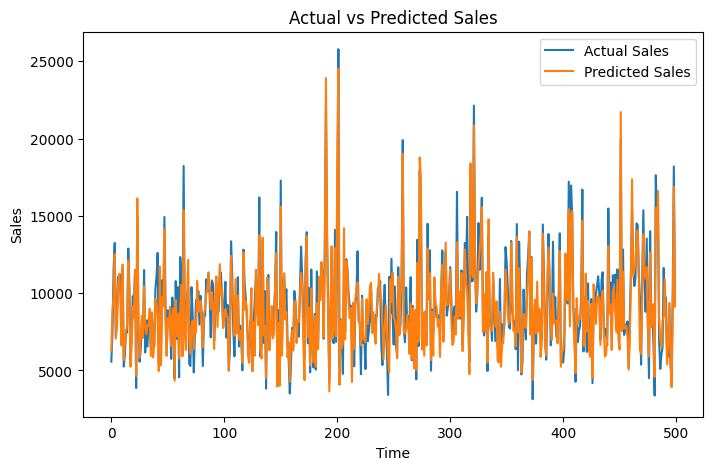

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    y_test_actual[:500],
    label="Actual Sales"
)

plt.plot(
    predictions_actual[:500],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.show()

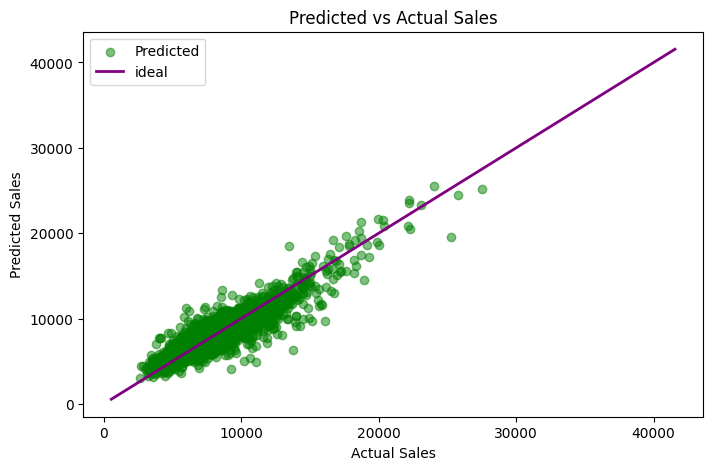

In [55]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_actual[:2000],
    predictions_actual[:2000],
    color="green",
    alpha=0.5,
    label="Predicted"
)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    color="purple",
    linewidth=2,
    label="ideal"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Predicted vs Actual Sales")
plt.legend()

plt.show()


The predicted vs actual sales plot shows a strong positive correlation between model predictions and true sales values.
Most points cluster closely around the ideal diagonal line, indicating that the LSTM model successfully captured underlying retail sales patterns with good forecasting accuracy.


The final multivariate LSTM forecasting model achieved an MAE of 752 sales units and an RMSE of 1124 on unseen test data across multiple Rossmann stores. Considering average daily store sales ranged between 6k–10k units, the model maintained forecasting errors within approximately 8–12%, demonstrating strong predictive performance for operational retail forecasting.”

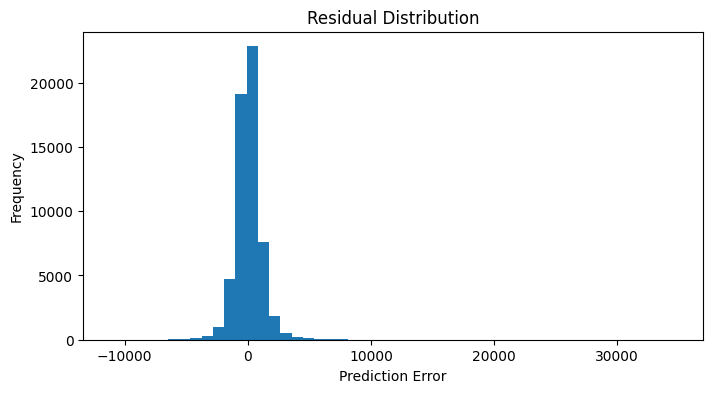

In [41]:
residuals = y_test_actual.flatten() - predictions_actual.flatten()

plt.figure(figsize=(8,4))

plt.hist(
    residuals,
    bins=50
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

TECHNICAL INSIGHT


---


Residuals were centered around zero with an approximately normal distribution, indicating that the LSTM model captured most temporal sales patterns effectively without strong systematic bias.


 BUISNESS INSIGHT


---

The residual analysis indicates that the forecasting model provides reliable day-to-day sales predictions for operational planning. Most prediction errors are concentrated near zero, suggesting stable forecasting performance, while larger errors during extreme sales periods highlight opportunities for future model improvements.


In [56]:
results = pd.DataFrame({

    "Actual": y_test_actual.flatten(),

    "Predicted": predictions_actual.flatten()

})

results.to_csv(

    f"{project_path}/outputs/final_predictions.csv",

    index=False

)